# Pandas Basics — Student Performance Data

A short, hands-on tour of the pandas skills you use on *every* dataset, on a tiny table with just three columns:

| Column | Meaning |
|---|---|
| `study_hours` | Hours studied per week |
| `attendance` | Class attendance, in percent |
| `result` | `Pass` or `Fail` |

**What we cover**

1. Reading the data and getting an overview — `head()`, `tail()`, `info()`, `describe()`
2. Handling **missing values**
3. Handling **duplicate rows**
4. Checking the **distribution** — boxplots and the **IQR** outlier rule
5. Selecting data with **`iloc`** and **`loc`**

Run the cells top to bottom.

## 0. Setup — create the dataset

Normally you would upload a CSV. To keep this notebook self-contained we *generate* a messy CSV first (with missing values, duplicates and a few extreme students baked in), then read it back exactly the way you would read a real file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(7)
n = 60

study_hours = np.round(rng.normal(5.0, 1.8, n).clip(0.5, 9.5), 1)
attendance  = np.round(rng.normal(80, 10, n).clip(45, 100), 0)

# a few extreme students, so the boxplot has something to show
study_hours[3]  = 17.5     # studies enormously
study_hours[21] = 15.0
attendance[9]   = 22.0     # barely shows up

score  = 0.55 * study_hours + 0.06 * attendance + rng.normal(0, 0.7, n)
result = np.where(score > 7.5, "Pass", "Fail")

df_raw = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "result": result,
})

# punch some holes in the data
df_raw.loc[[5, 18, 40], "study_hours"] = np.nan
df_raw.loc[[12, 33], "attendance"] = np.nan
df_raw.loc[[27], "result"] = np.nan

# and glue a few duplicated rows on the end
df_raw = pd.concat([df_raw, df_raw.iloc[[0, 1, 2, 0]]], ignore_index=True)

df_raw.to_csv("students.csv", index=False)
print("students.csv written:", df_raw.shape)

students.csv written: (64, 3)


## 1. Read the data

In [2]:
df = pd.read_csv("students.csv")
df

,study_hours,attendance,result
0,5.0,82.0,Pass
1,5.5,75.0,Fail
2,4.5,81.0,Fail
3,17.5,68.0,Pass
4,4.2,74.0,Fail
...,...,...,...
59,3.8,82.0,Fail
60,5.0,82.0,Pass
61,5.5,75.0,Fail
62,4.5,81.0,Fail


## 2. First overview

Four functions answer four different questions. Always run all four before you do anything else.

| Function | Question it answers |
|---|---|
| `head()` | What do the first rows look like? |
| `tail()` | What do the last rows look like? |
| `info()` | How many rows, what data types, how many non-null values? |
| `describe()` | What are the numbers like — mean, min, max, spread? |

In [3]:
# first 5 rows (df.head(10) for ten)
df.head()

,study_hours,attendance,result
0,5.0,82.0,Pass
1,5.5,75.0,Fail
2,4.5,81.0,Fail
3,17.5,68.0,Pass
4,4.2,74.0,Fail


In [4]:
# last 5 rows — great for spotting junk glued to the bottom of a file
df.tail()

,study_hours,attendance,result
59,3.8,82.0,Fail
60,5.0,82.0,Pass
61,5.5,75.0,Fail
62,4.5,81.0,Fail
63,5.0,82.0,Pass


In [5]:
# shape = (rows, columns);  columns = the names;  dtypes = the type of each column
print("shape  :", df.shape)
print("columns:", list(df.columns))
print()
print(df.dtypes)

shape  : (64, 3)
columns: ['study_hours', 'attendance', 'result']

study_hours    float64
attendance     float64
result             str
dtype: object


In [6]:
# info() = the one-stop health check: row count, non-null count per column, dtypes, memory
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  61 non-null     float64
 1   attendance   62 non-null     float64
 2   result       63 non-null     str    
dtypes: float64(2), str(1)
memory usage: 1.9 KB


Read `info()` like this: `study_hours` has fewer non-null values than the total number of rows, so **some values are missing**. We fix that in section 4.

In [7]:
# describe() summarises the NUMERIC columns
df.describe()

,study_hours,attendance
count,61.000000,62.000000
mean,5.104918,78.274194
std,2.576718,10.841888
min,0.500000,22.000000
25%,3.900000,75.000000
50%,4.900000,79.000000
75%,5.600000,83.750000
max,17.500000,100.000000


In [8]:
# for text / category columns, value_counts() is the equivalent
df["result"].value_counts()

result
Fail    42
Pass    21
Name: count, dtype: int64

In [9]:
# proportions instead of counts
df["result"].value_counts(normalize=True).round(3)

result
Fail    0.667
Pass    0.333
Name: proportion, dtype: float64

### A few quick illustrations

A picture of the data usually tells you more in two seconds than `describe()` does in twenty.

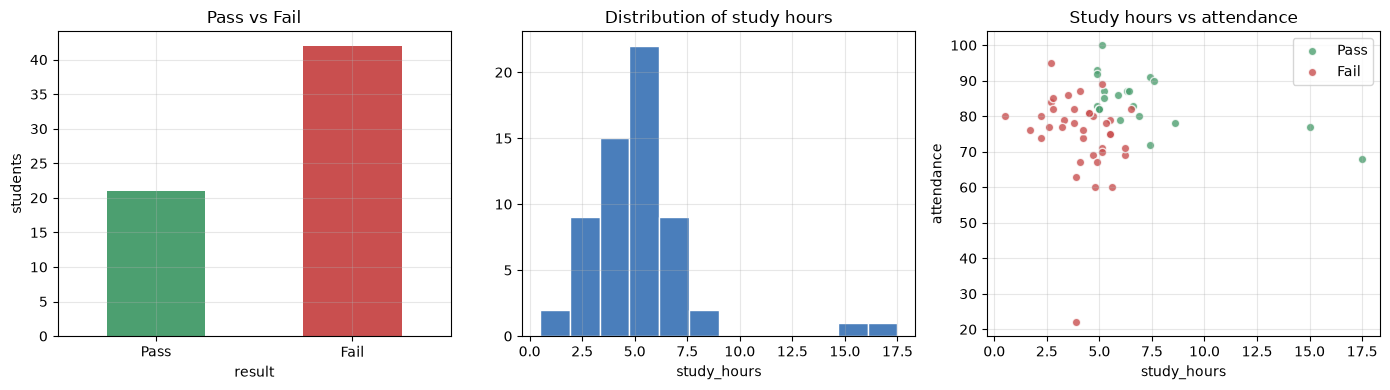

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. how many pass vs fail
#    reindex first: value_counts() sorts by size, so the order (and colour) would
#    otherwise flip depending on the data
counts = df["result"].value_counts().reindex(["Pass", "Fail"])
counts.plot(kind="bar", ax=axes[0], color=["#4c9f70", "#c94f4f"])
axes[0].set_title("Pass vs Fail")
axes[0].set_ylabel("students")
axes[0].tick_params(axis="x", rotation=0)

# 2. distribution of study hours
axes[1].hist(df["study_hours"].dropna(), bins=12, color="#4a7ebb", edgecolor="white")
axes[1].set_title("Distribution of study hours")
axes[1].set_xlabel("study_hours")

# 3. the two numeric columns against each other, coloured by outcome
for label, colour in [("Pass", "#4c9f70"), ("Fail", "#c94f4f")]:
    sub = df[df["result"] == label]
    axes[2].scatter(sub["study_hours"], sub["attendance"], label=label,
                    color=colour, alpha=0.8, edgecolor="white")
axes[2].set_xlabel("study_hours"); axes[2].set_ylabel("attendance")
axes[2].set_title("Study hours vs attendance")
axes[2].legend()

plt.tight_layout()
plt.show()

Already visible: the students who pass sit to the **right** (more hours) and **higher** (better attendance), and a few dots sit far away from the crowd — the extreme values we will catch with the IQR rule.

## 3. Duplicate rows

A duplicate is a row that is *identical* to another row. Usually it is an export or merge accident, and it quietly biases every average you compute.

- `df.duplicated()` → `True` / `False` per row (the **first** occurrence is `False`)
- `df.duplicated().sum()` → how many extra copies exist
- `df.drop_duplicates()` → keep the first, throw the rest away

In [11]:
print("duplicate rows:", df.duplicated().sum())

# show them
df[df.duplicated()]

duplicate rows: 5


,study_hours,attendance,result
40,NaN,77.0,Fail
60,5.0,82.0,Pass
61,5.5,75.0,Fail
62,4.5,81.0,Fail
63,5.0,82.0,Pass


In [12]:
# keep=False marks EVERY copy, including the original — handy for eyeballing
df[df.duplicated(keep=False)].sort_values("study_hours")

,study_hours,attendance,result
2,4.5,81.0,Fail
62,4.5,81.0,Fail
60,5.0,82.0,Pass
0,5.0,82.0,Pass
63,5.0,82.0,Pass
1,5.5,75.0,Fail
61,5.5,75.0,Fail
18,NaN,77.0,Fail
40,NaN,77.0,Fail


In [13]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"rows before: {before}  ->  rows after: {df.shape[0]}")

rows before: 64  ->  rows after: 59


## 4. Missing values

`NaN` = "not a number" = an empty cell. Two questions: **where** are they, and **what do we do** about them?

Common choices:

| Strategy | Code | When |
|---|---|---|
| Drop the rows | `df.dropna()` | Very few missing, or the *target* column is missing |
| Fill with the mean | `df["c"].fillna(df["c"].mean())` | Roughly symmetric numeric column |
| Fill with the median | `df["c"].fillna(df["c"].median())` | Numeric column with outliers (safer) |
| Fill with the mode | `df["c"].fillna(df["c"].mode()[0])` | Text / category column |

In [14]:
# where are they?
print(df.isnull().sum())
print("\ntotal missing cells:", df.isnull().sum().sum())

study_hours    2
attendance     2
result         1
dtype: int64

total missing cells: 5


In [15]:
# the rows that contain at least one missing value
df[df.isnull().any(axis=1)]

,study_hours,attendance,result
5,NaN,78.0,Fail
12,5.2,NaN,Fail
18,NaN,77.0,Fail
27,4.0,76.0,NaN
33,3.5,NaN,Fail


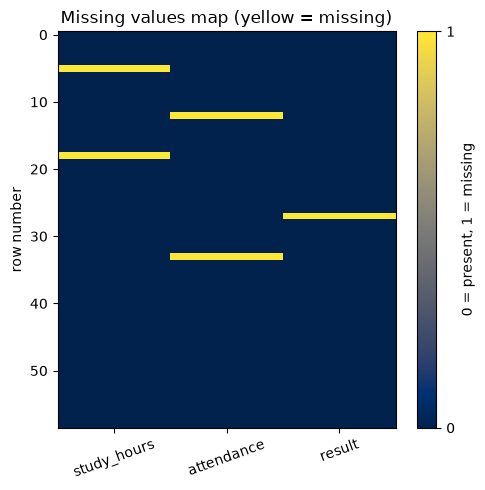

In [16]:
# a picture of the holes: yellow = missing
plt.figure(figsize=(5, 5))
plt.imshow(df.isnull(), aspect="auto", cmap="cividis", interpolation="nearest")
plt.xticks(range(df.shape[1]), df.columns, rotation=20)
plt.ylabel("row number")
plt.title("Missing values map (yellow = missing)")
plt.grid(False)
plt.colorbar(ticks=[0, 1], label="0 = present, 1 = missing")
plt.tight_layout()
plt.show()

In [17]:
# 1. the target column: we cannot invent a Pass/Fail, so drop those rows
df = df.dropna(subset=["result"]).reset_index(drop=True)

# 2. numeric columns: fill with the MEDIAN (unaffected by the extreme students)
for col in ["study_hours", "attendance"]:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col:<12} filled with median = {median_value}")

print("\nmissing values left:", df.isnull().sum().sum())
print("shape:", df.shape)

study_hours  filled with median = 4.9
attendance   filled with median = 79.0

missing values left: 0
shape: (58, 3)


## 5. Distribution and outliers — boxplot + the IQR rule

A **boxplot** shows five numbers at once:

```
        Q1      median      Q3
   |-----[=======|==========]-----|      o     o
 lower                            upper   outliers
 whisker                          whisker
```

- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1 (the width of the middle 50% of the data)
- Anything below **Q1 − 1.5 × IQR** or above **Q3 + 1.5 × IQR** is flagged as an **outlier**

That 1.5 × IQR rule is exactly what draws the dots outside the whiskers.

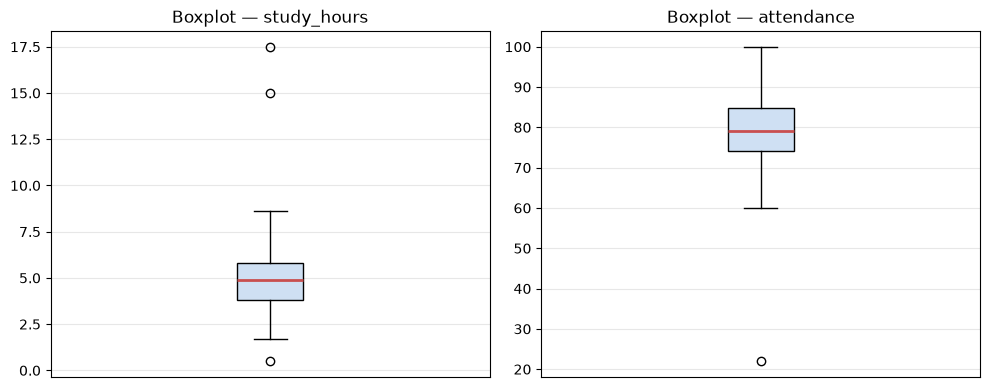

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["study_hours", "attendance"]):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor="#cfe0f3"),
               medianprops=dict(color="#c94f4f", linewidth=2))
    ax.set_title(f"Boxplot — {col}")
    ax.set_xticks([])
plt.tight_layout()
plt.show()

In [19]:
# the same five numbers, as text
df[["study_hours", "attendance"]].describe().loc[["min", "25%", "50%", "75%", "max"]]

,study_hours,attendance
min,0.500,22.00
25%,3.825,74.25
50%,4.900,79.00
75%,5.825,84.75
max,17.500,100.00


In [20]:
def iqr_bounds(series):
    """Return (Q1, Q3, IQR, lower_bound, upper_bound) for one column."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["study_hours", "attendance"]:
    q1, q3, iqr, low, high = iqr_bounds(df[col])
    outliers = df[(df[col] < low) | (df[col] > high)]
    print(f"--- {col} ---")
    print(f"Q1 = {q1:.2f}   Q3 = {q3:.2f}   IQR = {iqr:.2f}")
    print(f"acceptable range: {low:.2f} to {high:.2f}")
    print(f"outliers found  : {len(outliers)}  -> {list(outliers[col].values)}\n")

--- study_hours ---
Q1 = 3.82   Q3 = 5.83   IQR = 2.00
acceptable range: 0.82 to 8.83
outliers found  : 3  -> [np.float64(17.5), np.float64(15.0), np.float64(0.5)]

--- attendance ---
Q1 = 74.25   Q3 = 84.75   IQR = 10.50
acceptable range: 58.50 to 100.50
outliers found  : 1  -> [np.float64(22.0)]



In [21]:
# build a mask that is True for every row inside the bounds of BOTH numeric columns
mask = pd.Series(True, index=df.index)
for col in ["study_hours", "attendance"]:
    _, _, _, low, high = iqr_bounds(df[col])
    mask &= df[col].between(low, high)

df_outliers = df[~mask]
df_clean = df[mask].reset_index(drop=True)

print("outlier rows removed:", len(df_outliers))
print("clean shape         :", df_clean.shape)
df_outliers

outlier rows removed: 4
clean shape         : (54, 3)


,study_hours,attendance,result
3,17.5,68.0,Pass
9,3.9,22.0,Fail
21,15.0,77.0,Pass
26,0.5,80.0,Fail


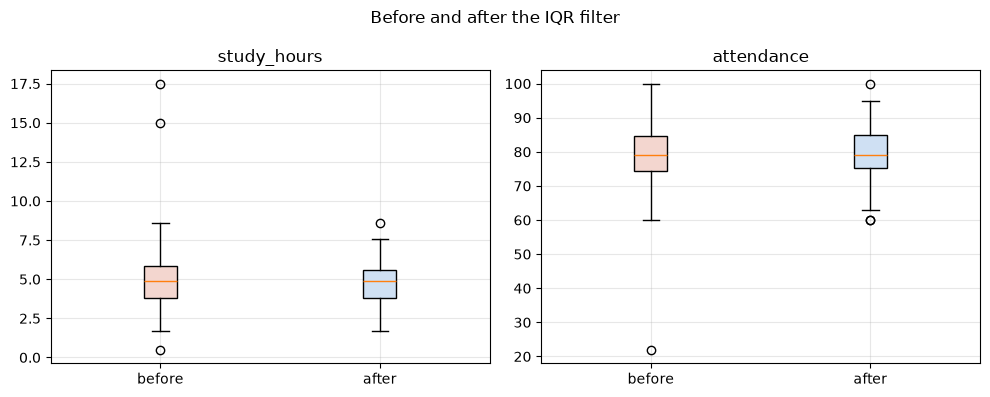

In [22]:
# before / after — one panel per column, so each keeps its own scale
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["study_hours", "attendance"]):
    bp = ax.boxplot([df[col], df_clean[col]], patch_artist=True)
    for patch, colour in zip(bp["boxes"], ["#f3d6cf", "#cfe0f3"]):
        patch.set_facecolor(colour)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["before", "after"])
    ax.set_title(col)
plt.suptitle("Before and after the IQR filter")
plt.tight_layout()
plt.show()

Two things to take away from that picture:

- The extreme values are gone and the boxes now fill the plot properly.
- **New dots appear outside the whiskers.** That is not a bug: once the extremes are removed, the IQR shrinks, so the 1.5 × IQR fence moves inwards and the next-most-unusual points fall outside it. Chasing that to zero would eat your dataset — you run the rule **once**, deliberately.

> **Note:** removing outliers is a *decision*, not a rule. A student who really does study 17 hours a week is valid data. Drop them only when they are errors or when they distort the model you are building — and always say that you did.

## 6. Selecting data — `iloc` vs `loc`

This is the single most confused pair in pandas:

| | `iloc` | `loc` |
|---|---|---|
| Selects by | **position** (integer) | **label** (index / column name) |
| `0` means | the first row | the row whose index *is* `0` |
| Slice `1:4` | rows 1, 2, 3 — end **excluded** | rows 1 to 4 — end **included** |
| Conditions | ✗ | ✓ `df.loc[df["x"] > 5]` |

Memory hook: **i**loc = **i**nteger, **loc** = **l**abel.

In [23]:
# ---- iloc: everything is a POSITION ----
print("first row:")
print(df_clean.iloc[0], "\n")

print("value at row 0, column 0:", df_clean.iloc[0, 0], "\n")

print("rows 0-4, all columns:")
display(df_clean.iloc[0:5])

first row:
study_hours     5.0
attendance     82.0
result         Pass
Name: 0, dtype: object 

value at row 0, column 0: 5.0 

rows 0-4, all columns:


,study_hours,attendance,result
0,5.0,82.0,Pass
1,5.5,75.0,Fail
2,4.5,81.0,Fail
3,4.2,74.0,Fail
4,4.9,78.0,Fail


In [24]:
# rows 0-4, first two columns only (end position excluded on both sides)
df_clean.iloc[0:5, 0:2]

,study_hours,attendance
0,5.0,82.0
1,5.5,75.0
2,4.5,81.0
3,4.2,74.0
4,4.9,78.0


In [25]:
# a scattered pick: specific rows AND specific columns, by position
df_clean.iloc[[0, 3, 7], [0, 2]]

,study_hours,result
0,5.0,Pass
3,4.2,Fail
7,4.1,Fail


In [26]:
# last 3 rows, negative positions work like Python lists
df_clean.iloc[-3:]

,study_hours,attendance,result
51,6.2,71.0,Fail
52,7.6,90.0,Pass
53,3.8,82.0,Fail


In [27]:
# ---- loc: everything is a LABEL ----
# rows labelled 0 to 4  -> note 4 IS included, unlike iloc
df_clean.loc[0:4, ["study_hours", "result"]]

,study_hours,result
0,5.0,Pass
1,5.5,Fail
2,4.5,Fail
3,4.2,Fail
4,4.9,Fail


In [28]:
# the real power of loc: boolean conditions
df_clean.loc[df_clean["study_hours"] > 7]

,study_hours,attendance,result
6,7.4,91.0,Pass
38,7.4,72.0,Pass
43,8.6,78.0,Pass
52,7.6,90.0,Pass


In [29]:
# combine conditions with &  (and)  |  (or) — each condition in its own brackets
hard_workers = df_clean.loc[
    (df_clean["study_hours"] > 6) & (df_clean["attendance"] > 85),
    ["study_hours", "attendance", "result"]
]
print("students with >6 h AND >85% attendance:", len(hard_workers))
hard_workers

students with >6 h AND >85% attendance: 4


,study_hours,attendance,result
6,7.4,91.0,Pass
13,6.3,87.0,Pass
44,6.4,87.0,Pass
52,7.6,90.0,Pass


In [30]:
# loc also WRITES. Add a column, then set it only where a condition holds.
df_clean["risk"] = "ok"
df_clean.loc[(df_clean["study_hours"] < 4) | (df_clean["attendance"] < 70), "risk"] = "at risk"

print(df_clean["risk"].value_counts(), "\n")
df_clean.head(10)

risk
ok         33
at risk    21
Name: count, dtype: int64 



,study_hours,attendance,result,risk
0,5.0,82.0,Pass,ok
1,5.5,75.0,Fail,ok
2,4.5,81.0,Fail,ok
3,4.2,74.0,Fail,ok
4,4.9,78.0,Fail,ok
5,5.1,89.0,Fail,ok
6,7.4,91.0,Pass,ok
7,4.1,67.0,Fail,at risk
8,5.9,86.0,Pass,ok
9,5.6,60.0,Fail,at risk


In [31]:
# cross-check the flag against the real outcome
pd.crosstab(df_clean["risk"], df_clean["result"])

result,Fail,Pass
risk,,
at risk,21,0
ok,16,17


## 7. Where we ended up

In [32]:
summary = pd.DataFrame({
    "stage": ["raw file", "after drop_duplicates", "after dropna on result", "after IQR filter"],
    "rows":  [len(df_raw), len(df_raw.drop_duplicates()), len(df), len(df_clean)],
})
print(summary.to_string(index=False))
print()
print("final missing values:", df_clean.isnull().sum().sum())
print("final duplicates    :", df_clean.duplicated().sum())
df_clean.describe()

                 stage  rows
              raw file    64
 after drop_duplicates    59
after dropna on result    58
      after IQR filter    54

final missing values: 0
final duplicates    : 0


,study_hours,attendance
count,54.000000,54.000000
mean,4.820370,79.462963
std,1.492798,8.428865
min,1.700000,60.000000
25%,3.825000,75.250000
50%,4.900000,79.000000
75%,5.575000,85.000000
max,8.600000,100.000000


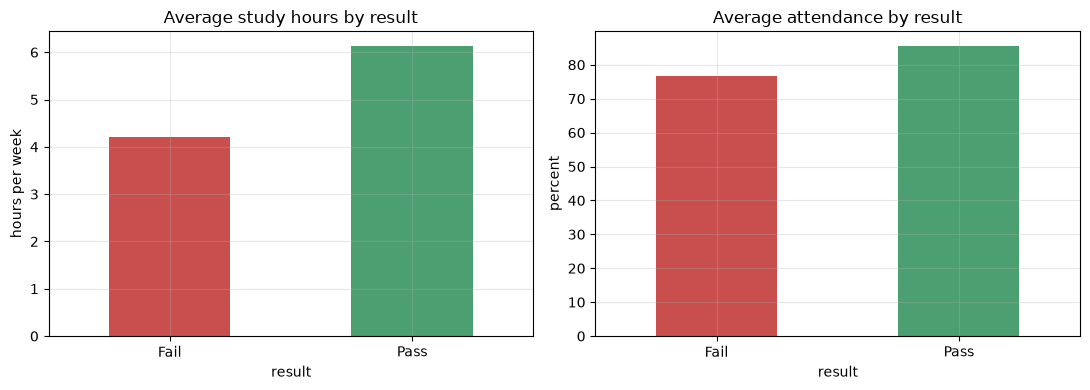

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_clean.groupby("result")["study_hours"].mean().plot(
    kind="bar", ax=axes[0], color=["#c94f4f", "#4c9f70"])
axes[0].set_title("Average study hours by result")
axes[0].set_ylabel("hours per week")
axes[0].tick_params(axis="x", rotation=0)

df_clean.groupby("result")["attendance"].mean().plot(
    kind="bar", ax=axes[1], color=["#c94f4f", "#4c9f70"])
axes[1].set_title("Average attendance by result")
axes[1].set_ylabel("percent")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. Your turn

Try these in a new cell — every one uses something from above:

1. Show the **last 8** rows of `df_clean` using `tail()`, then the same 8 rows using `iloc`.
2. How many students have `attendance` **exactly 100**? (`loc` + a condition)
3. Fill missing `study_hours` with the **mean** instead of the median on a fresh `pd.read_csv("students.csv")` — does `describe()` change much? Why?
4. Apply the IQR rule to `attendance` **only**, and count how many rows you would lose.
5. Use `df_clean.groupby("risk")[["study_hours", "attendance"]].mean()` — does the `risk` flag separate the two groups cleanly?

### Cheat sheet

```python
df.head(n) / df.tail(n)       # peek at top / bottom
df.shape / df.columns / df.dtypes
df.info()                     # types + non-null counts
df.describe()                 # numeric summary
df["col"].value_counts()      # category counts

df.isnull().sum()             # missing per column
df.dropna(subset=["col"])     # drop rows missing that column
df["col"].fillna(df["col"].median())

df.duplicated().sum()         # count duplicates
df.drop_duplicates()

q1, q3 = df["col"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr

df.iloc[0:5, 0:2]             # by POSITION, end excluded
df.loc[0:4, ["a", "b"]]       # by LABEL, end included
df.loc[df["a"] > 5, "b"] = 0  # conditional read AND write
```